# Model 6 - Deeper GAP CNN (`gap_deep`)

Adds **one extra conv block (256 filters)** on top of the GAP model - the single
change vs model 2. Plain GAP still had an ~8% train-val gap, suggesting spare
capacity; this tests whether a deeper network uses it to push past 0.74. No
augmentation, so it's a clean depth-only comparison.

## 1. Setup & imports

Shared pipeline modules; uses the deeper GAP factory.

In [1]:
import os
import sys

sys.path.append(os.path.join(os.getcwd(), "preprocessing", "label_mapping"))
sys.path.append(os.path.join(os.getcwd(), "preprocessing", "data_loader"))
sys.path.append(os.path.join(os.getcwd(), "model"))
sys.path.append(os.path.join(os.getcwd(), "evaluation", "model_metrics"))
sys.path.append(os.path.join(os.getcwd(), "evaluation", "plots"))

import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping

from label_mapping import build_labeled_dataset
from data_loader import build_train_val_test_generators
from gap_deep_cnn import build_gap_deep_cnn
from model_metrics import debug_model, evaluate_model, record_result
from plots import plot_misclassified

## 2. Load & label the dataset

Build the image index (Italian folder -> English label, root-relative paths).

In [2]:
df = build_labeled_dataset()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26179 entries, 0 to 26178
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  26179 non-null  object
 1   label_it    26179 non-null  object
 2   label_en    26179 non-null  object
dtypes: object(3)
memory usage: 613.7+ KB


## 3. Preprocess: split, resize, normalize

Identical preprocessing to models 1-3 (128x128, rescale 1/255, no augmentation)
so depth is the only variable.

In [3]:
train_generator, val_generator, test_generator = build_train_val_test_generators(
    df, project_root=os.getcwd(), image_size=(128, 128)
)
train_generator.class_indices

Found 18325 validated image filenames belonging to 10 classes.
Found 3927 validated image filenames belonging to 10 classes.
Found 3927 validated image filenames belonging to 10 classes.


{'butterfly': 0,
 'cat': 1,
 'chicken': 2,
 'cow': 3,
 'dog': 4,
 'elephant': 5,
 'horse': 6,
 'sheep': 7,
 'spider': 8,
 'squirrel': 9}

## 4. Build the CNN (deeper GAP)

The GAP model plus a **fourth conv block of 256 filters** - ~1.17M params vs the
GAP model's ~288k. More capacity to learn finer features.

In [4]:
model = build_gap_deep_cnn(
    input_shape=train_generator.image_shape,
    num_classes=len(train_generator.class_indices),
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,174,826 (4.48 MB)

 Trainable params: 1,174,826 (4.48 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train - or load a saved model

If `models_saved/gap_deep.keras` exists it's **loaded**; otherwise it trains and
is saved. Same config as the GAP model (`patience=3`, up to 30 epochs) - only the
depth differs. Set `RETRAIN = True` to force a fresh run.

In [5]:
import time
from tensorflow import keras

# Load the saved model if present so a kernel restart doesn't cost a full
# retrain. Delete the file or set RETRAIN=True to train fresh.
MODEL_PATH = "models_saved/gap_deep.keras"
RETRAIN = False

if not RETRAIN and os.path.exists(MODEL_PATH):
    model = keras.models.load_model(MODEL_PATH)
    history, train_time_min = None, None
    print(f"Loaded {MODEL_PATH} (skipped training).")
else:
    early_stopping = EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True
    )
    start_time = time.time()
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=30,
        callbacks=[early_stopping],
    )
    train_time_min = round((time.time() - start_time) / 60, 1)
    print(f"Trained in {train_time_min} min.")

Loaded models_saved/gap_deep.keras (skipped training).


## 6. Training history

A deeper net can overfit faster - watch whether `acc_gap` widens back toward the
baseline's level.

In [6]:
# Training history - only when we actually trained this run.
if history is not None:
    history_df = pd.DataFrame(history.history)
    history_df.index.name = "epoch"
    history_df["acc_gap"] = history_df["accuracy"] - history_df["val_accuracy"]
    display(history_df)
else:
    print("Model was loaded from disk - no training history this run.")

Model was loaded from disk - no training history this run.


## 7. Evaluate: per-class report + confusion matrix

Score on the validation set; per-class precision/recall/F1 + confusion-matrix
heatmap.

123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step
              precision    recall  f1-score   support

   butterfly       0.00      0.00      0.00       317
         cat       0.00      0.00      0.00       250
     chicken       0.00      0.00      0.00       464
         cow       0.00      0.00      0.00       280
         dog       0.19      1.00      0.31       730
    elephant       0.00      0.00      0.00       217
       horse       0.00      0.00      0.00       393
       sheep       0.00      0.00      0.00       273
      spider       0.00      0.00      0.00       723
    squirrel       0.00      0.00      0.00       280

    accuracy                           0.19      3927
   macro avg       0.02      0.10      0.03      3927
weighted avg       0.03      0.19      0.06      3927



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


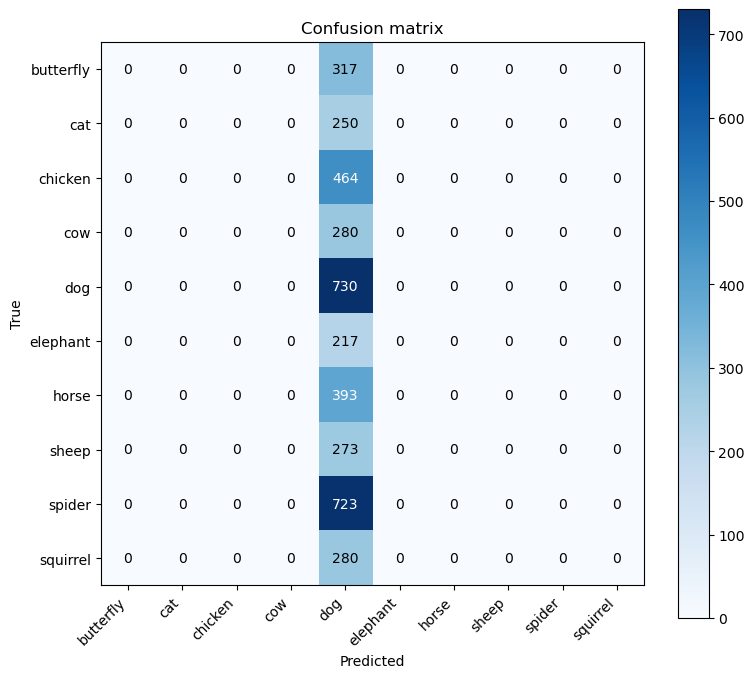

,butterfly,cat,chicken,cow,dog,elephant,horse,sheep,spider,squirrel
butterfly,0,0,0,0,317,0,0,0,0,0
cat,0,0,0,0,250,0,0,0,0,0
chicken,0,0,0,0,464,0,0,0,0,0
cow,0,0,0,0,280,0,0,0,0,0
dog,0,0,0,0,730,0,0,0,0,0
elephant,0,0,0,0,217,0,0,0,0,0
horse,0,0,0,0,393,0,0,0,0,0
sheep,0,0,0,0,273,0,0,0,0,0
spider,0,0,0,0,723,0,0,0,0,0
squirrel,0,0,0,0,280,0,0,0,0,0


In [7]:
debug_model(model, val_generator)

## 8. Misclassified images

Grid of validation images the model got wrong (true -> pred).

123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step


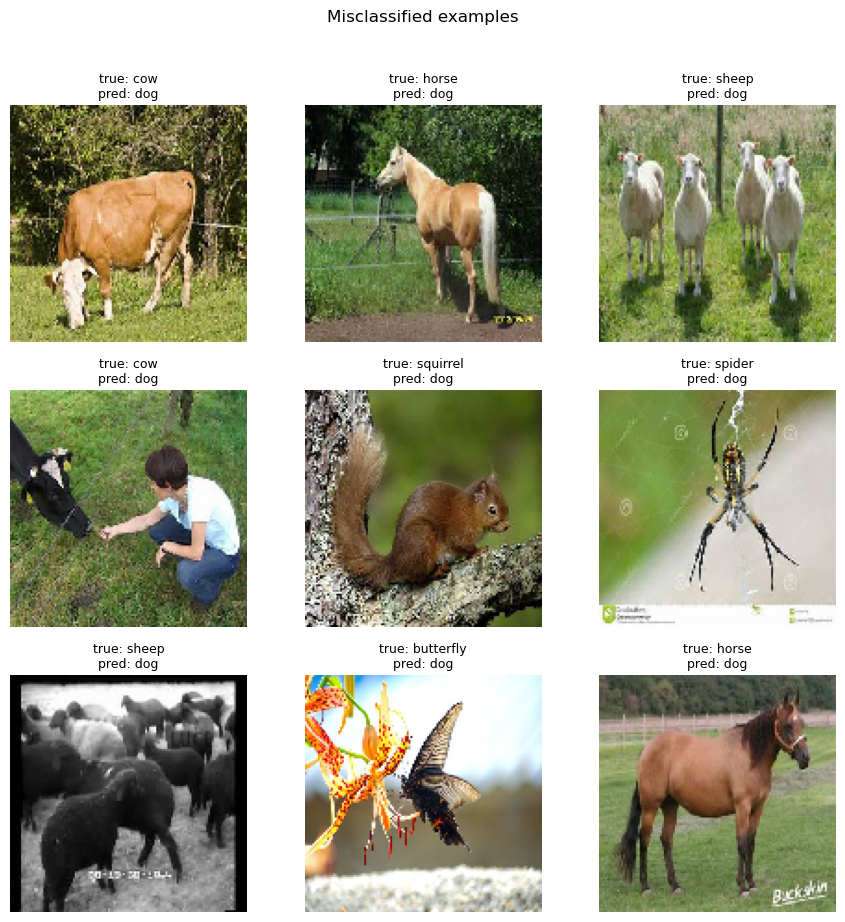

In [8]:
plot_misclassified(model, val_generator)

## 9. Record result to the tracking sheet

Upsert this model's validation row into `model_tracking.csv`.

In [9]:
learning_rate = round(float(model.optimizer.learning_rate.numpy()), 6)

row = evaluate_model(model, val_generator, "gap_deep")
row.update({
    "architecture": "4 conv blocks (8 Conv, +256) -> GlobalAveragePooling -> Dropout(0.5)",
    "learning_rate": learning_rate,
    "train_time_min": train_time_min,
    "notes": "Deeper GAP: extra 256-filter block (~1.17M params). Test if more capacity beats plain GAP.",
})
record_result(row)

123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step


,model,architecture,learning_rate,train_time_min,accuracy,precision,recall,f1,notes
0,baseline_cnn,3 conv blocks (6 Conv) -> Flatten -> Dropout(0.5),0.001,15.6,0.6988,0.6875,0.6569,0.6677,Baseline (val metrics). Overfits (~13% train-v...
1,gap_cnn,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,32.3,0.7403,0.7321,0.7111,0.7136,Flatten -> GAP (val metrics). Less overfit (~8...
2,gap_bn_cnn,3 conv blocks (Conv-BN-ReLU) -> GlobalAverageP...,0.001,62.6,0.6924,0.7526,0.6448,0.6593,GAP + BatchNorm (val metrics). Test if BN beat...
3,gap_aug,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,47.3,0.6677,0.6511,0.6433,0.6300,GAP + train augmentation (flip/rotate/shift/zo...
4,gap_aug2,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,54.7,0.7179,0.7065,0.7053,0.6895,Augmentation retry: dropout 0.3 + 60 epochs. T...
5,gap_deep,"4 conv blocks (8 Conv, +256) -> GlobalAverageP...",0.001,14.6,0.1859,0.0186,0.1000,0.0314,Deeper GAP: extra 256-filter block (~1.17M par...


## 10. Save the model

Save only when freshly trained (a loaded model is already on disk).

In [10]:
if history is not None:
    os.makedirs("models_saved", exist_ok=True)
    model.save(MODEL_PATH)
    print(f"Saved {MODEL_PATH}")
else:
    print(f"Using existing {MODEL_PATH}")

Using existing models_saved/gap_deep.keras


## 11. Compare all models

Bar chart of validation accuracy across every recorded model.

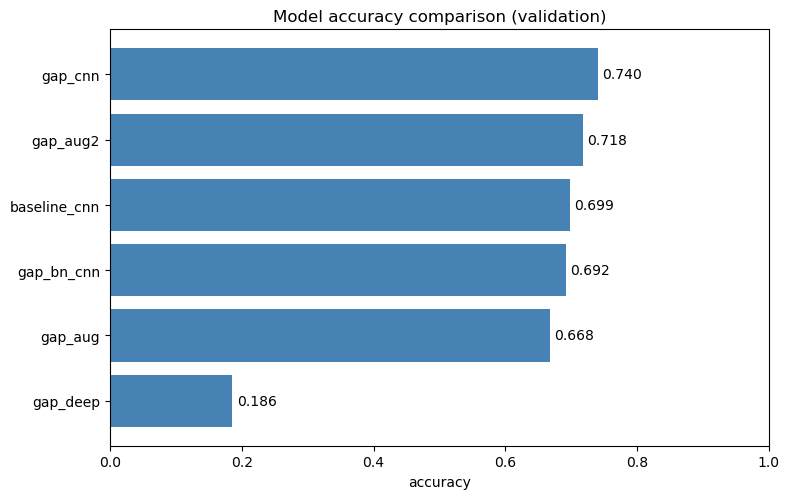

,model,architecture,learning_rate,train_time_min,accuracy,precision,recall,f1,notes
5,gap_deep,"4 conv blocks (8 Conv, +256) -> GlobalAverageP...",0.001,14.6,0.1859,0.0186,0.1000,0.0314,Deeper GAP: extra 256-filter block (~1.17M par...
3,gap_aug,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,47.3,0.6677,0.6511,0.6433,0.6300,GAP + train augmentation (flip/rotate/shift/zo...
2,gap_bn_cnn,3 conv blocks (Conv-BN-ReLU) -> GlobalAverageP...,0.001,62.6,0.6924,0.7526,0.6448,0.6593,GAP + BatchNorm (val metrics). Test if BN beat...
0,baseline_cnn,3 conv blocks (6 Conv) -> Flatten -> Dropout(0.5),0.001,15.6,0.6988,0.6875,0.6569,0.6677,Baseline (val metrics). Overfits (~13% train-v...
4,gap_aug2,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,54.7,0.7179,0.7065,0.7053,0.6895,Augmentation retry: dropout 0.3 + 60 epochs. T...
1,gap_cnn,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,32.3,0.7403,0.7321,0.7111,0.7136,Flatten -> GAP (val metrics). Less overfit (~8...


In [11]:
from model_metrics import plot_accuracy_comparison

plot_accuracy_comparison()